# Exploratory Data Analysis 

## 1. Dataset overview

First, we inspect the basic characteristics of the curated dataset. This includes the number of compounds available for modelling and the structure of the variables describing each molecule. These summary statistics provide a reference point for the subsequent analyses.

In [67]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Import curated data from drug_db.py
from drug_db import df_DrugBank_clean, cyp_counter

print(f"Data loaded from drug_db.py")
print(f"   - Total molecules: {len(df_DrugBank_clean)}")

Data loaded from drug_db.py
   - Total molecules: 1368


### Selection of the frequency threshold

To ensure that every CYP isoform retained in the benchmark was sufficiently represented during the final evaluation, a minimum frequency threshold of **50 annotated molecules** was applied. Given the fixed **80/20 train-test split**, this guarantees that each retained CYP is expected to contribute **at least approximately 10 positive examples** to the independent test set. This provides a minimum basis for obtaining meaningful performance estimates while excluding CYP isoforms supported by only a handful of observations.

The following analysis summarizes the effect of applying this threshold to both the CYP label space and the number of retained molecules.

In [68]:
THRESHOLD = 50 

# CYPs below threshold (to be filtered out)
uncommon_cyps = [k for k, v in cyp_counter.items() if v < THRESHOLD]

# Counter with only the CYPs that exceed the threshold (for plots)
cyp_counter_filtered = Counter({k: v for k, v in cyp_counter.items() if v >= THRESHOLD})

# Apply the filter to the DataFrame
df_all = df_DrugBank_clean.copy()
df_all["CYPs_filtered"] = df_all["CYPs"].apply(
    lambda cyps: [c for c in cyps if c not in uncommon_cyps]
)

# DataFrame that we will use for modeling: only molecules with at least one CYP after filtering
df_filtered = df_all[df_all["CYPs_filtered"].map(len) > 0].copy()

print(f"Threshold selected: {THRESHOLD}")
print(f"   - Total CYPs: {len(cyp_counter)}")
print(f"   - CYPs that exceed the threshold: {len(cyp_counter_filtered)}")
print(f"   - Molecules with at least one CYP after filtering: {len(df_filtered)}")
print(f"   - Molecules with no CYPs after filtering: {len(df_all) - len(df_filtered)} ({(len(df_all) - len(df_filtered)) / len(df_all) * 100:.2f}%)")

Threshold selected: 50
   - Total CYPs: 33
   - CYPs that exceed the threshold: 13
   - Molecules with at least one CYP after filtering: 1354
   - Molecules with no CYPs after filtering: 14 (1.02%)


Applying the threshold reduces the original set of **33 CYP isoforms to 13**, while retaining **1,354 of the 1,368 molecules** in the curated dataset. Only **14 compounds (~1.0%)** are excluded because none of their annotated CYPs belong to the retained set. This represents a minimal loss of data while ensuring that every CYP included in the benchmark has sufficient representation for reliable evaluation on the held-out test set.

## 2. CYP isoenzyme frequency

The first step is to quantify how frequently each CYP450 isoenzyme appears across the dataset. Because each molecule may be metabolized by multiple enzymes, every annotation is counted independently. This analysis provides an overview of the label distribution and identifies the most and least represented CYP isoforms.

In [73]:
# Create a table with all CYPs, sorted from highest to lowest frequency
df_freq_all = pd.DataFrame(
    [(cyp, count) for cyp, count in cyp_counter.items()],
    columns=["CYP", "DrugCount"]
)
df_freq_all["Percentage"] = round(df_freq_all["DrugCount"] / len(df_all) * 100, 2)
df_freq_all = df_freq_all.sort_values("DrugCount", ascending=False).reset_index(drop=True)

print(f"\nCYPs with frequency >= {THRESHOLD}:")
display(df_freq_all[df_freq_all["DrugCount"] >= THRESHOLD].style.hide(axis="index"))


CYPs with frequency >= 50:


CYP,DrugCount,Percentage
CYP3A4,1051,76.830000
CYP2D6,417,30.480000
CYP2C9,415,30.340000
CYP1A2,339,24.780000
CYP3A5,337,24.630000
CYP2C19,335,24.490000
CYP2C8,318,23.250000
CYP2B6,223,16.300000
CYP3A7,179,13.080000
CYP2E1,140,10.230000


### CYP distribution

A bar plot provides a direct visualization of the number of molecules associated with each CYP isoenzyme. The large differences in frequency between enzymes can be readily observed, with a small number of CYPs accounting for a substantial proportion of the available annotations.

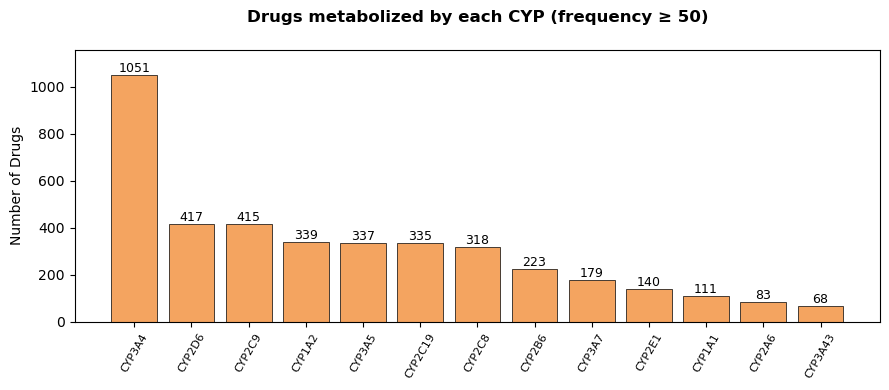

In [62]:
# Sort in descending order
sorted_items = sorted(cyp_counter_filtered.items(), key=lambda x: x[1], reverse=True)
names, values = zip(*sorted_items)

plt.figure(figsize=(9, 4))
bars = plt.bar(names, values, color="sandybrown", edgecolor="black", linewidth=0.5)

# Bar labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=9)

plt.ylabel("Number of Drugs", fontsize=10)
plt.xticks(rotation=60, ha="center", fontsize=8)
plt.title(f"Drugs metabolized by each CYP (frequency ≥ {THRESHOLD})", pad=20, fontweight="bold")
plt.tight_layout()
plt.ylim(0, max(values) * 1.1)
plt.show()

### Long-tail distribution

To better visualize less frequent CYP isoforms, the same distribution is displayed using a logarithmic scale including low-frequency CYPs (gray). This representation makes the long-tail behaviour of the dataset more apparent by allowing both abundant and rare enzymes to be visualized simultaneously.

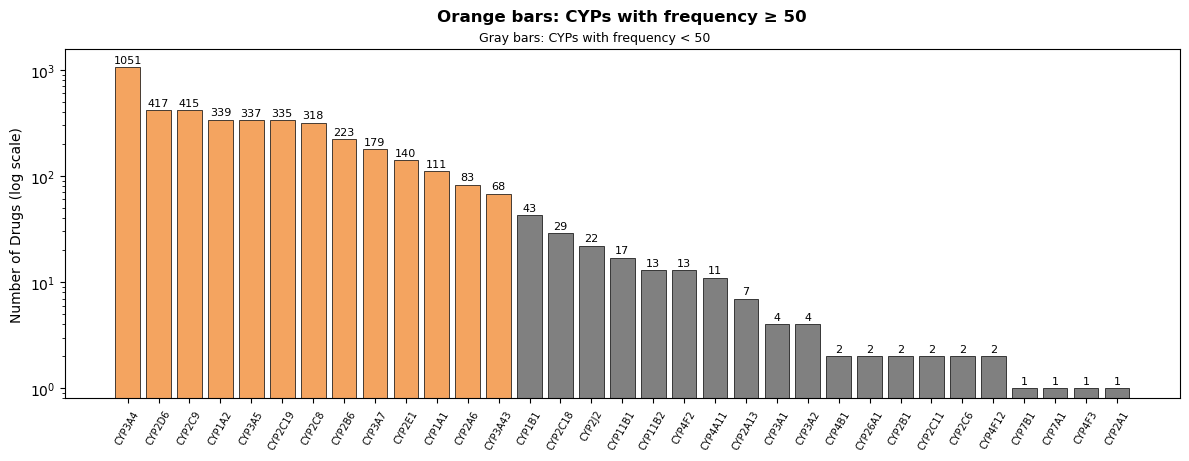

In [64]:
# Ensure sorted DataFrame for plotting
df_freq_all_sorted = df_freq_all.sort_values("DrugCount", ascending=False)

all_cyps = df_freq_all_sorted["CYP"].values
all_counts = df_freq_all_sorted["DrugCount"].values
colours = ["sandybrown" if c >= THRESHOLD else "gray" for c in all_counts]

plt.figure(figsize=(12, 5))
bars = plt.bar(all_cyps, all_counts, color=colours, edgecolor="black", linewidth=0.5)

# Value labels only for those with count > 0
for bar, count in zip(bars, all_counts):
    if count > 0:
        plt.text(bar.get_x() + bar.get_width()/2, count * 1.05,
                 str(count), ha='center', va='bottom', fontsize=8)

plt.yscale('log')
plt.ylabel("Number of Drugs (log scale)", fontsize=10)
plt.xticks(rotation=60, ha="center", fontsize=7)
plt.title(f"Orange bars: CYPs with frequency ≥ {THRESHOLD}", pad=20, fontweight="bold")
plt.suptitle(f"Gray bars: CYPs with frequency < {THRESHOLD}", fontsize=9, y=0.87)
plt.ylim(0.8, max(all_counts) * 1.5)
plt.tight_layout()
plt.show()

## Multi-label characteristics

Drug metabolism is inherently a multi-label problem because a single compound may be metabolized by several CYP isoenzymes simultaneously. To characterize this property, the number of associated CYPs is calculated for every molecule and its distribution is examined.

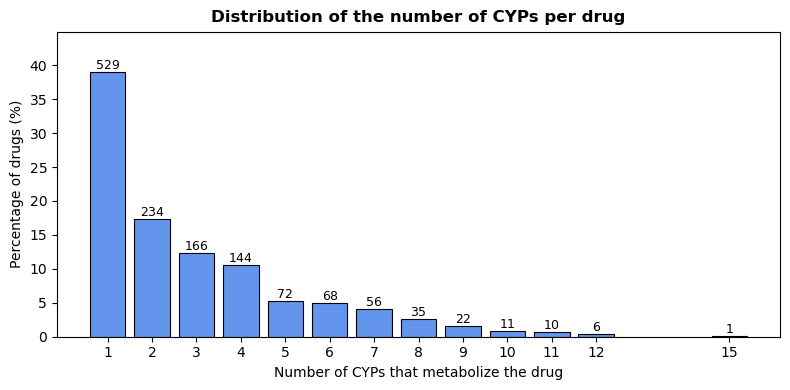

Summary of the number of CYPs per drug:
count    1354.000000
mean        2.966027
std         2.395555
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        15.000000
Name: CYPs_filtered, dtype: float64
   - Drugs with 1 CYP: 529 (39.07%)
   - Drugs with >=2 CYPs: 825 (60.93%)
   - Max number of CYPs for a drug: 15 CYPs
   - Drug with the most CYPs: Midostaurin


In [ ]:
# CYP count per drug
num_cyps = df_filtered["CYPs_filtered"].apply(len)

# Calculate frequencies and percentages
counts = num_cyps.value_counts().sort_index()
total = len(df_filtered)
percentages = (counts / total) * 100

# Stats
print("Summary of the number of CYPs per drug:")
print(num_cyps.describe())
print(f"   - Drugs with 1 CYP: {sum(num_cyps == 1)} ({sum(num_cyps == 1) / len(df_filtered) * 100:.2f}%)")
print(f"   - Drugs with >=2 CYPs: {sum(num_cyps >= 2)} ({sum(num_cyps >= 2) / len(df_filtered) * 100:.2f}%)")
print(f"   - Max number of CYPs for a drug: {num_cyps.max()} CYPs")
print(f"   - Drug with the most CYPs: {df_filtered.loc[num_cyps.idxmax(), 'Name']}")

### Number of labels per molecule

The following distribution illustrates how many CYP isoforms are associated with each compound. While some molecules are metabolized by a single enzyme, many involve multiple CYPs, confirming the multi-label nature of the prediction task.

In [ ]:
plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, percentages, color="cornflowerblue", edgecolor="black", linewidth=0.8)

# Annotate each bar with the absolute count (placed above the bar)
for bar, count in zip(bars, counts.values):
    height = bar.get_height()

    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(count), ha='center', va='bottom', fontsize=9)

plt.xlabel("Number of CYPs that metabolize the drug")
plt.ylabel("Percentage of drugs (%)")
plt.ylim(0, max(percentages) * 1.15)  # leave room for labels
plt.title(f"Distribution of the number of CYPs per drug", pad=7, fontweight="bold")
plt.xticks(counts.index)
plt.tight_layout()
plt.show()

### CYP co-occurrence heatmap

Beyond individual frequencies, it is informative to examine which CYP isoforms tend to appear together within the same molecule. A co-occurrence matrix quantifies these pairwise relationships and provides an overview of common metabolic combinations present in the dataset.

The heatmap visualizes the frequency with which pairs of CYP isoforms co-occur across all compounds. Stronger colour intensity indicates more frequent joint occurrence, allowing common enzyme combinations to be identified at a glance.

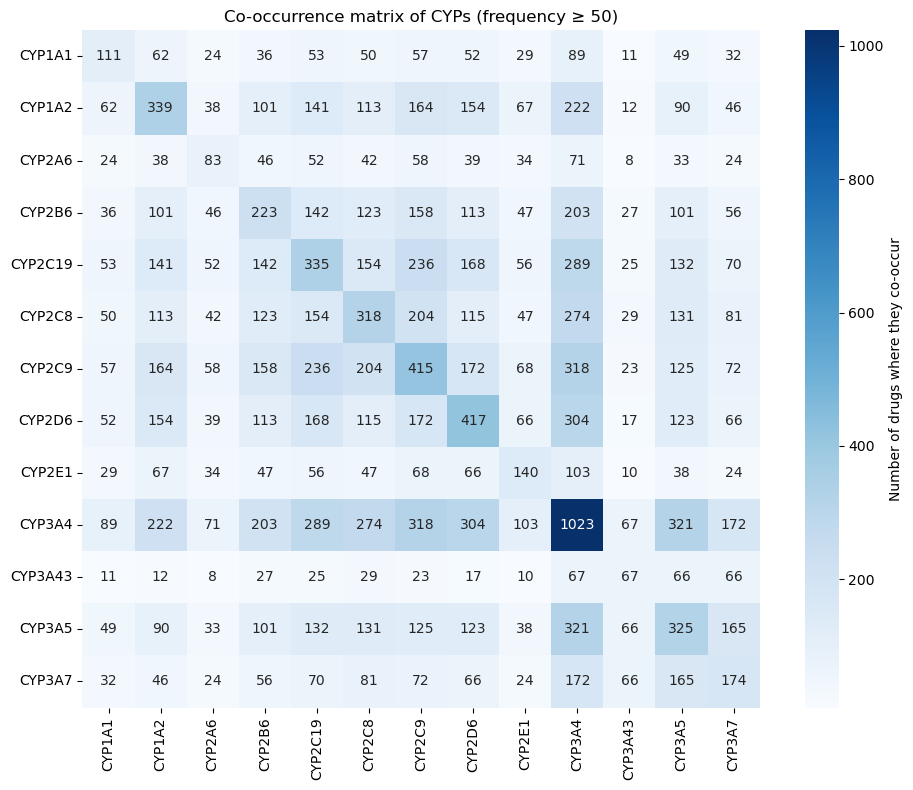

In [26]:
import seaborn as sns
# Only CYPs that exceed the threshold
cyps_list = sorted(cyp_counter_filtered.keys())
n_cyps = len(cyps_list)

# Initialize matrix of zeros
co_occ = np.zeros((n_cyps, n_cyps), dtype=int)

# Fill the matrix by counting pairs
for cyps in df_filtered["CYPs_filtered"]:
    cyps_set = set(cyps)
    for i, c1 in enumerate(cyps_list):
        if c1 in cyps_set:
            for j, c2 in enumerate(cyps_list):
                if c2 in cyps_set:
                    co_occ[i, j] += 1

# Convert to DataFrame for the heatmap
df_co_occ = pd.DataFrame(co_occ, index=cyps_list, columns=cyps_list)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(df_co_occ, annot=True, fmt='d', cmap='Blues', square=True,
            cbar_kws={'label': 'Number of drugs where they co-occur'})
plt.title(f"Co-occurrence matrix of CYPs (frequency ≥ {THRESHOLD})")
plt.tight_layout()
plt.show()

### Effect of frequency filtering

Applying the frequency threshold may exclude compounds whose metabolic annotations consist exclusively of removed CYP isoforms. The following analysis quantifies the impact of this filtering step on the final dataset used for model development.

In [27]:
# Molecules that lose all CYP annotations after filtering
lost_molecules = df_all[df_all["CYPs_filtered"].map(len) == 0]
num_lost = len(lost_molecules)
total = len(df_all)
pct_lost = (num_lost / total) * 100

print(f"Total molecules: {total}")
print(f"Molecules that lose all CYP annotations after applying threshold={THRESHOLD}: {num_lost} ({pct_lost:.2f}%)")

if num_lost > 0:
    print("\nExamples of affected molecules (last 5):")
    display(lost_molecules[["DrugBank ID", "Name", "CYPs"]].tail())

Total molecules: 1368
Molecules that lose all CYP annotations after applying threshold=50: 14 (1.02%)

Examples of affected molecules (last 5):


,DrugBank ID,Name,CYPs
1030,DB11156,Pyrantel,[CYP4A11]
1198,DB13125,Lusutrombopag,[CYP4A11]
1345,DB15636,Zilucoplan,[CYP4F2]
1383,DB11077,"3,6,9,12,15,18,21,24,27,30,33,36,39,42,45-Pent...",[CYP4A11]
1384,DB11077,Triethylene glycol,[CYP4A11]


In [29]:
stereo_chars = ['@', '/', '\\']

def has_stereo(smiles):
    return any(ch in smiles for ch in stereo_chars)

df_all["has_stereo"] = df_all["SMILES"].apply(has_stereo)
num_stereo = df_all["has_stereo"].sum()
total = len(df_all)

print(f"\n Total molecules: {total}")
print(f" Molecules with SMILES containing stereochemistry: {num_stereo} ({num_stereo/total*100:.2f}%)")
print(f" Molecules without apparent stereochemistry: {total - num_stereo} ({(total-num_stereo)/total*100:.2f}%)")


 Total molecules: 1368
 Molecules with SMILES containing stereochemistry: 689 (50.37%)
 Molecules without apparent stereochemistry: 679 (49.63%)


## EDA summary

The metabolism dataset exhibits a pronounced long-tail distribution, with a small number of CYP isoforms accounting for most metabolic annotations. Most compounds are associated with more than one CYP, confirming that the prediction task is inherently multi-label. Applying the frequency threshold removes only the least represented enzymes while preserving the majority of compounds, resulting in a more statistically robust benchmark dataset for the subsequent modelling stage.